<a href="https://colab.research.google.com/github/JCedrix/caller-companion/blob/main/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Caller Companion - Exploratory Data Analysis

Predicting term deposit subscription from the UCI Bank Marketing dataset.

This notebook is the data exploration phase for the Caller Companion, a tool that helps a call-center agent have a better conversation before they dial. The model is the briefing. The agent is the driver.

**Dataset:** UCI Bank Marketing (bank-additional-full)

**Target:** `y` - did the customer subscribe to a term deposit (yes/no)

**Rows:** around 41,000 contacts from a Portuguese banking institution, 2008 to 2010

## Setup

Loading the core libraries I'll need throughout the notebook: pandas for the dataframe, numpy for math, matplotlib and seaborn for visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# display settings so the notebook reads cleanly
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')

print("Libraries loaded.")

Libraries loaded.


## Loading the data

I'm pulling the dataset directly from the UCI Machine Learning Repository so anyone running this notebook can reproduce it without a manual download. The file uses semicolons as separators instead of commas, and it lives inside a zip with multiple files, so I'm unpacking it and grabbing `bank-additional-full.csv` specifically.

In [4]:
import zipfile
import io
import requests

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip"

# download the zip and open the specific CSV we want
response = requests.get(url)
with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    with z.open('bank-additional/bank-additional-full.csv') as f:
        df = pd.read_csv(f, sep=';')

print(f"Loaded {len(df):,} rows and {df.shape[1]} columns.")

Loaded 41,188 rows and 21 columns.


## First look

Before touching any modeling, I want to understand the shape of what I'm working with. Three things I'm checking:

- What features are here and what types are they
- Whether there are any obvious missing values
- What a single row actually looks like

In [5]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Column types and structure

Checking what pandas inferred for each column and looking for any actual NaN values.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

**Observations:**

- 41,188 rows, 21 columns (20 features + target)
- 11 categorical columns, 10 numeric
- Every column shows full non-null count, no NaN values anywhere

That last point is misleading though. The dataset encodes missing values as the literal string `'unknown'` rather than as NaN, so a naive missingness check looks clean even when it isn't. I'll check for that explicitly next.

## The "unknown" trap

The categorical features use `'unknown'` as their missing value indicator. Counting how many `'unknown'` entries appear in each categorical column, and what percent of the dataset that represents.

In [7]:
categorical_cols = df.select_dtypes(include='object').columns

unknown_counts = (df[categorical_cols] == 'unknown').sum()
unknown_pct = (df[categorical_cols] == 'unknown').mean() * 100

unknown_summary = pd.DataFrame({
    'unknown_count': unknown_counts,
    'unknown_pct': unknown_pct.round(2)
})
unknown_summary[unknown_summary['unknown_count'] > 0].sort_values('unknown_count', ascending=False)

,unknown_count,unknown_pct
default,8597,20.87
education,1731,4.20
housing,990,2.40
loan,990,2.40
job,330,0.80
marital,80,0.19


**Observations:**

- `default` is the standout, with 21% of customers showing `unknown`. That's not random missingness, it's the bank's records breaking down on a sensitive field. The missingness itself is probably informative.
- `housing` and `loan` both show exactly 990 unknowns. Almost certainly the same 990 customers, likely a batch of records with incomplete loan data.
- `education`, `job`, and `marital` have small enough unknown rates that they shouldn't cause modeling issues.

I'm going to treat `unknown` as its own category rather than imputing or dropping. If missingness correlates with subscription behavior, the model should be allowed to learn that.

## Class balance

The target column `y` is a yes/no flag for whether the customer subscribed to the term deposit. Before training anything, I need to know how imbalanced this is, because that shapes which metrics matter and how I'll set up the train/test split later.

In [8]:
class_counts = df['y'].value_counts()
class_pct = df['y'].value_counts(normalize=True) * 100

print("Class counts:")
print(class_counts)
print(f"\nPositive class rate: {class_pct['yes']:.2f}%")

Class counts:
y
no     36548
yes     4640
Name: count, dtype: int64

Positive class rate: 11.27%


**Observations:**

- 36,548 customers said no, 4,640 said yes
- Positive class rate is 11.27%

That imbalance shapes everything downstream:

- Accuracy is misleading here. A model that always predicts "no" hits 88.73% accuracy and is useless to a call-center agent.
- I'll evaluate with ROC-AUC and PR-AUC instead of accuracy.
- Any train/test split needs to be stratified to preserve the 11% rate in both halves.
- The logistic regression baseline will use `class_weight='balanced'` so it doesn't ignore the minority class.
- I'll likely tune the classification threshold below 0.5 to surface more potential subscribers, accepting some false positives as the cost.

## The duration leak

This is the most important check in the entire notebook. The `duration` column records how long a call lasted in seconds. The UCI dataset documentation explicitly notes that this attribute "highly affects the output target (e.g., if duration=0 then y='no')" and recommends discarding it for any realistic predictive model.

The reasoning is simple: duration is only known *after* the call ends. My Caller Companion gives the agent a prediction *before* they dial. So duration cannot exist at prediction time, and including it would train a model that looks accurate in the notebook but is useless to the agent.

I'm going to confirm the leak by checking the correlation of every numeric feature with the target, and then I'll drop the column.

In [9]:
# convert y to numeric so we can compute correlations
y_numeric = (df['y'] == 'yes').astype(int)

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

correlations = df[numeric_cols].apply(lambda col: col.corr(y_numeric)).sort_values(key=abs, ascending=False)

print("Correlation of each numeric feature with subscription:")
print(correlations.round(3))

Correlation of each numeric feature with subscription:
duration          0.405
nr.employed      -0.355
pdays            -0.325
euribor3m        -0.308
emp.var.rate     -0.298
previous          0.230
cons.price.idx   -0.136
campaign         -0.066
cons.conf.idx     0.055
age               0.030
dtype: float64


**Observations:**

- `duration` correlates with subscription at 0.405, the strongest signal in the dataset.
- The next strongest features are macroeconomic indicators: `nr.employed` (-0.355), `pdays` (-0.325), `euribor3m` (-0.308), `emp.var.rate` (-0.298). These reflect the 2008 financial crisis context. Customers leaned toward safer products like term deposits as the economy contracted.
- `age` shows almost no linear correlation (0.030). That doesn't mean it's useless - non-linear models may still find patterns in age groups.

Dropping `duration` in the next step. The 2008 macroeconomic features are also worth flagging as a generalization concern for the Model Report.

## Dropping duration

Removing `duration` from the dataframe so I can't accidentally use it during modeling. I'm storing it in a separate variable in case I want to reference it for analysis or honesty comparisons later, but it does not enter the feature set.

In [10]:
# preserve duration separately for later reference, but remove it from the modeling dataframe
duration_held_out = df['duration'].copy()
df = df.drop(columns=['duration'])

print(f"Dataframe now has {df.shape[1]} columns (was 21, dropped duration).")
print(f"Held-out duration values stored separately: {len(duration_held_out):,} values.")

Dataframe now has 20 columns (was 21, dropped duration).
Held-out duration values stored separately: 41,188 values.


## Subscription rate by job

Different occupations have different relationships with banking products. Retirees tend to have disposable savings and time to take a call. Students are often pulled into financial products by parents or are first-time investors. Blue-collar workers may be unreachable during the workday. I want to see if those patterns show up in the data.

In [11]:
job_subscription = df.groupby('job').apply(
    lambda x: (x['y'] == 'yes').mean() * 100
).sort_values(ascending=False)

print("Subscription rate by job category (%):")
print(job_subscription.round(2))

Subscription rate by job category (%):
job
student          31.43
retired          25.23
unemployed       14.20
admin.           12.97
management       11.22
unknown          11.21
technician       10.83
self-employed    10.49
housemaid        10.00
entrepreneur      8.52
services          8.14
blue-collar       6.89
dtype: float64


/tmp/ipykernel_1571/1389232127.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  job_subscription = df.groupby('job').apply(


**Observations:**

- Students subscribe at 31.4%, retirees at 25.2%. That's 3-4x the dataset average of 11.27%.
- Blue-collar workers are at the bottom at 6.9%, well below average.
- The gap between top and bottom is roughly 4.5x. Job is a strong categorical predictor.

This mirrors patterns I'd expect from outbound calling work: reachability and decision-maker status matter as much as need. Retirees answer the phone and have disposable savings. Blue-collar workers are at job sites during business hours and harder to convert on a cold call.

The model should be able to use this signal cleanly once the categorical is encoded.

## Subscription rate by previous outcome (poutcome)

The `poutcome` column records what happened the last time this customer was contacted in a marketing campaign. Three possible values: `success` (they subscribed before), `failure` (they didn't), or `nonexistent` (no prior campaign).

This is the feature I expect to carry the most signal of any single column, because past behavior is usually the strongest predictor of future behavior.

In [12]:
poutcome_subscription = df.groupby('poutcome', observed=True)['y'].apply(
    lambda x: (x == 'yes').mean() * 100
).sort_values(ascending=False)

poutcome_counts = df['poutcome'].value_counts()

print("Subscription rate by previous outcome (%):")
print(poutcome_subscription.round(2))
print("\nNumber of customers in each group:")
print(poutcome_counts)

Subscription rate by previous outcome (%):
poutcome
success        65.11
failure        14.23
nonexistent     8.83
Name: y, dtype: float64

Number of customers in each group:
poutcome
nonexistent    35563
failure         4252
success         1373
Name: count, dtype: int64


**Observations:**

- Prior successes subscribe again at 65.1%, almost 6x the dataset average.
- Prior failures still subscribe at 14.2%, slightly above the dataset average. Even a "no" last time is a softer signal than no contact at all.
- 86% of customers have no prior campaign history (`nonexistent`), and only 3.3% are in the `success` bucket.

`poutcome` is by far the strongest categorical signal in the dataset, but it carries a rich-get-richer risk. A model that leans heavily on it will recommend calling customers who have already subscribed before, which inflates measured success at the cost of new customer acquisition.

I'll keep `poutcome` as a feature because the signal is real, but the Caller Companion should surface *why* a prediction is high. If the top contributing factor is "prior subscription," the agent should know they're being pointed at a returning customer, not a fresh prospect. That's an agent-facing transparency decision, not a modeling one.

## Subscription rate by age group

Earlier I saw that `age` had almost zero linear correlation with subscription (0.030). That number is misleading though. Linear correlation only captures monotonic relationships - "as age goes up, subscription goes up" or vice versa. If the relationship is non-linear, for example if both very young and very old customers subscribe more than middle-aged ones, linear correlation hides it completely.

Binning age into groups and looking at subscription rates per group should reveal whether there's a non-linear pattern worth capturing.

In [14]:
age_bins = [0, 25, 35, 45, 55, 65, 100]
age_labels = ['under 25', '25-34', '35-44', '45-54', '55-64', '65+']
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=False)

age_subscription = df.groupby('age_group', observed=True)['y'].apply(
    lambda x: (x == 'yes').mean() * 100
)
age_counts = df['age_group'].value_counts().sort_index()

print("Subscription rate by age group (%):")
print(age_subscription.round(2))
print("\nNumber of customers per age group:")
print(age_counts)

Subscription rate by age group (%):
age_group
under 25    23.97
25-34       12.17
35-44        8.65
45-54        8.65
55-64       13.57
65+         47.21
Name: y, dtype: float64

Number of customers per age group:
age_group
under 25     1068
25-34       13686
35-44       13500
45-54        8704
55-64        3567
65+           663
Name: count, dtype: int64


**Observations:**

- Sharp U-shape across age. Under-25 converts at 24%, 65+ at 47%, while ages 35-54 sit at 8.65% (below the dataset average of 11.27%).
- Linear correlation of 0.030 completely missed this pattern, because the U-shape averages out to near zero on a monotonic measure.
- The 65+ bucket likely overlaps heavily with the `retired` job category. Same underlying population, two views of it.
- 82% of customers fall in the flat middle range, so the high-converting bookends contribute fewer absolute subscribers in raw counts than their conversion rates suggest.

This is a strong argument for tree-based models. LightGBM can split on conditions like "age < 25 OR age > 65" natively. Logistic regression would need manual binning or polynomial features to capture the same pattern, and I'd have to know about the U-shape in advance to construct those features.

I'm going to drop the temporary `age_group` column now since the binning was just for visualization. The model will work on raw `age` and let the tree splits find the pattern.

In [15]:
# drop the temporary visualization column, keep age as a numeric feature
df = df.drop(columns=['age_group'])

print(f"Dataframe back to {df.shape[1]} columns.")

Dataframe back to 20 columns.


## Visualization summary

Three plots that capture the most important patterns from the analysis above. These are the visuals I'll reference in the Model Report and the demo.

### Class imbalance

The first thing any model has to contend with: the target is heavily skewed toward "no."

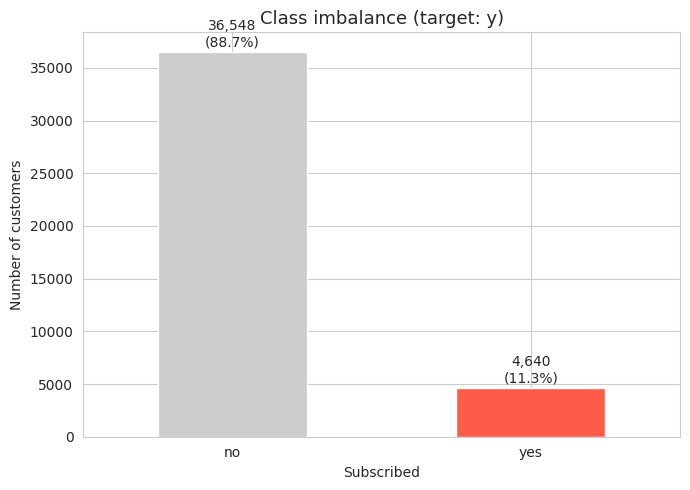

In [18]:
fig, ax = plt.subplots(figsize=(7, 5))

class_counts.plot(kind='bar', ax=ax, color=['#cccccc', '#ff5b4a'])
ax.set_title('Class imbalance (target: y)', fontsize=13)
ax.set_xlabel('Subscribed')
ax.set_ylabel('Number of customers')
ax.set_xticklabels(['no', 'yes'], rotation=0)

for i, v in enumerate(class_counts.values):
    ax.text(i, v + 500, f'{v:,}\n({class_pct.values[i]:.1f}%)',
            ha='center', fontsize=10)

plt.tight_layout()
plt.show()

**Observations:**

- 88.7% no, 11.3% yes. The "no" bar is roughly 8x taller than the "yes" bar.
- This is the visual proof that accuracy is the wrong metric. A model predicting "no" for everyone would land at 88.7% accuracy and identify zero subscribers.
- All downstream evaluation will use ROC-AUC and PR-AUC, and the training pipeline needs class weighting and stratified splits to handle this imbalance properly.

### Subscription rate by job

Sorted by conversion rate, with the dataset average marked as a reference line.

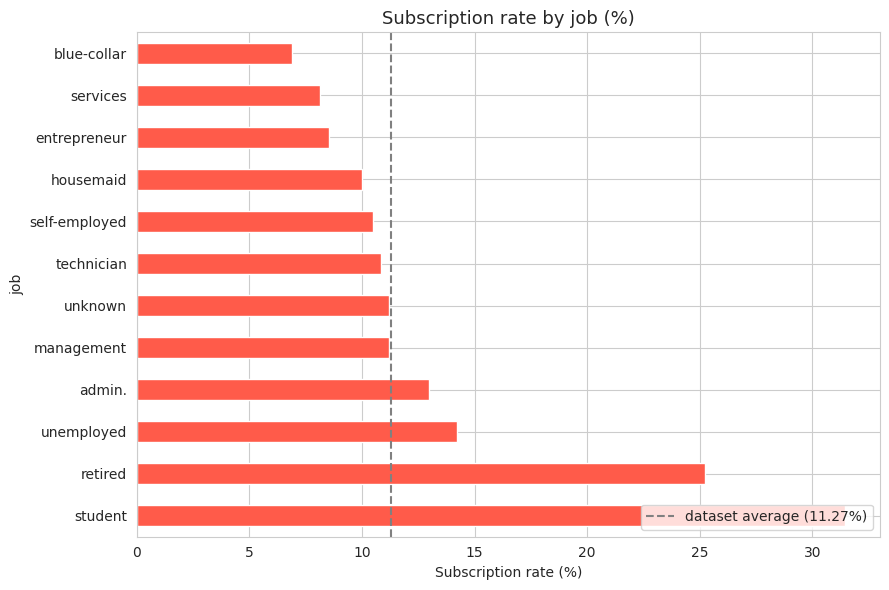

In [19]:
fig, ax = plt.subplots(figsize=(9, 6))

job_subscription.plot(kind='barh', ax=ax, color='#ff5b4a')
ax.set_title('Subscription rate by job (%)', fontsize=13)
ax.set_xlabel('Subscription rate (%)')
ax.axvline(11.27, color='gray', linestyle='--', linewidth=1.5, label='dataset average (11.27%)')
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

**Observations:**

- Students (31%) and retirees (25%) are the only two categories that beat the dataset average by more than 2x.
- Blue-collar workers are at the bottom at 6.9%, the only group meaningfully below average.
- Most other categories cluster between 8% and 13%, close to the dataset baseline.

For the Caller Companion, this means job is one of the strongest categorical signals. The agent should know going into the call whether they're dialing a high-conversion profile (student, retired) or a low-conversion one (blue-collar, services). The model will encode this automatically through one-hot or native LightGBM categorical handling.

### Subscription rate by age group

The U-shape that the linear correlation completely missed.

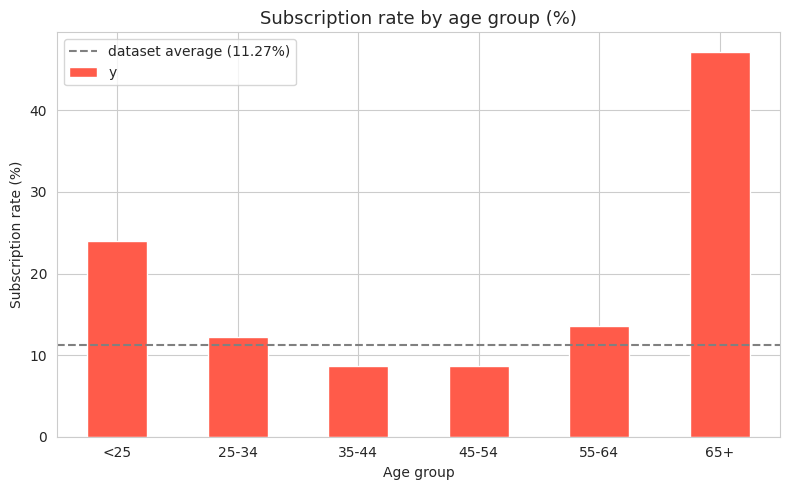

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))

age_bins = [0, 25, 35, 45, 55, 65, 100]
age_labels = ['<25', '25-34', '35-44', '45-54', '55-64', '65+']
age_temp = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=False)
age_sub_temp = df.groupby(age_temp, observed=True)['y'].apply(lambda x: (x == 'yes').mean() * 100)

age_sub_temp.plot(kind='bar', ax=ax, color='#ff5b4a')
ax.set_title('Subscription rate by age group (%)', fontsize=13)
ax.set_xlabel('Age group')
ax.set_ylabel('Subscription rate (%)')
ax.axhline(11.27, color='gray', linestyle='--', linewidth=1.5, label='dataset average (11.27%)')
ax.legend()
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

**Observations:**

- Clear U-shape. Under-25 subscribes at 24%, the 65+ group at 47%. Both extremes well above the dataset average.
- The 35-54 middle is flat at 8.65%, below average.
- Linear correlation reported age at 0.030, essentially zero. That number was misleading - it averaged the strong positive signal at the extremes into a near-zero result.

This is the strongest argument for the tree-based model choice I'll make in Phase 2. LightGBM can split on conditions like "age < 25 OR age > 65" natively. Logistic regression would only learn this if I manually engineered the bins as features, and I'd need to know about the U-shape in advance to do that. Trees discover it for free.

## Findings

Wrapping up the EDA with the five most important takeaways. These will carry forward into the modeling phase and the Model Report.

1. **Heavy class imbalance.** 11.27% positive rate. Accuracy is the wrong metric. Evaluation will use ROC-AUC and PR-AUC, training will use class weighting and stratified splits.

2. **`unknown` is the real missing value indicator.** Pandas reports zero NaN values, but six categorical columns contain `'unknown'` as a string. `default` is the worst offender at 21% unknown. I'm treating `unknown` as its own category rather than imputing, because the missingness itself may be informative.

3. **The duration leak.** `duration` has the strongest correlation with the target (0.405), but it's only known after the call ends. Including it would inflate every metric and produce a model that's useless to the agent at prediction time. I dropped it from the feature set.

4. **`poutcome` is the strongest categorical signal.** Customers who subscribed in a previous campaign convert at 65%, almost 6x the dataset average. Only 3.3% of customers fall in this bucket though, so the signal is sharp but rare. I'm keeping the feature but surfacing the reason behind a high prediction in the agent-facing UI to avoid over-marketing to repeat subscribers.

5. **Age has a non-linear U-shape.** Linear correlation reported 0.030, essentially zero. Binning revealed under-25 at 24% and 65+ at 47%, with the middle ages near 8.65%. This justifies the choice of a tree-based model (LightGBM) over logistic regression for the main predictor.

**Macroeconomic context.** Several of the strongest numeric correlations (`nr.employed`, `euribor3m`, `emp.var.rate`, `cons.price.idx`) are macroeconomic indicators from the 2008-2010 Portuguese economy. The model will use them, but they make the trained model time-bound. This is a generalization concern worth flagging in the Model Report.

**Next:** modeling phase. Stratified train/test split, baseline logistic regression with class weighting, LightGBM with 5-fold stratified cross-validation, threshold tuning, predictions.csv export, feature importance for the agent talking points.